# SWIGGY SALES ANALYSIS

### Import Libraries

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

### Import Data

In [16]:
df = pd.read_excel("C:/Users/chira/Desktop/swiggy_data.xlsx")

In [20]:
df.head(10)

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
0,Karnataka,Bengaluru,2025-06-29,Anand Sweets & Savouries,Rajarajeshwari Nagar,Snack,Butter Murukku-200gm,133.9,4.0,0
1,Karnataka,Bengaluru,2025-04-03,Srinidhi Sagar Deluxe,Kengeri,Recommended,Badam Milk,52.0,4.5,25
2,Karnataka,Bengaluru,2025-01-15,Srinidhi Sagar Deluxe,Kengeri,Recommended,Chow Chow Bath,117.0,4.7,48
3,Karnataka,Bengaluru,2025-04-17,Srinidhi Sagar Deluxe,Kengeri,Recommended,Kesari Bath,65.0,4.6,65
4,Karnataka,Bengaluru,2025-03-13,Srinidhi Sagar Deluxe,Kengeri,Recommended,Mix Raitha,130.0,4.0,0
5,Karnataka,Bengaluru,2025-07-08,Srinidhi Sagar Deluxe,Kengeri,Recommended,Srinidhi Sagar Special,312.0,4.0,0
6,Karnataka,Bengaluru,2025-01-21,Srinidhi Sagar Deluxe,Kengeri,Recommended,Garlic Naan,98.0,4.0,34
7,Karnataka,Bengaluru,2025-04-13,Srinidhi Sagar Deluxe,Kengeri,Recommended,Pista,137.0,4.0,0
8,Karnataka,Bengaluru,2025-05-02,Srinidhi Sagar Deluxe,Kengeri,North Indian Gravy,Panneer Butter Masala,241.0,4.4,29
9,Karnataka,Bengaluru,2025-07-30,Srinidhi Sagar Deluxe,Kengeri,North Indian Gravy,Dal Tadka,195.0,4.9,51


In [23]:
df.tail(10)

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
197420,Sikkim,Gangtok,2025-02-09,Mama's Kitchen,Gangtok,Momos,Mushroom cheese steam momo ...,112.0,4.4,0
197421,Sikkim,Gangtok,2025-07-28,Mama's Kitchen,Gangtok,Momos,Mushroom cheese fried momo ...,126.0,4.4,0
197422,Sikkim,Gangtok,2025-03-17,Mama's Kitchen,Gangtok,Momos,Mushroom cheese chilli momo ...,140.0,4.4,0
197423,Sikkim,Gangtok,2025-06-18,Mama's Kitchen,Gangtok,Momos,Soya cheese steam momo ...,84.0,4.4,0
197424,Sikkim,Gangtok,2025-08-11,Mama's Kitchen,Gangtok,Momos,Soya cheese fried momo ...,98.0,4.4,0
197425,Sikkim,Gangtok,2025-01-25,Mama's Kitchen,Gangtok,Momos,Soya cheese chilli momo ...,112.0,4.4,0
197426,Sikkim,Gangtok,2025-07-02,Mama's Kitchen,Gangtok,Momos,Kurkure momo fried ...,140.0,4.4,0
197427,Sikkim,Gangtok,2025-03-25,Mama's Kitchen,Gangtok,Momos,Chilli cheese momo,126.0,4.4,0
197428,Sikkim,Gangtok,2025-03-26,Mama's Kitchen,Gangtok,Momos,Veg Momos (8 Pc),85.0,4.4,0
197429,Sikkim,Gangtok,2025-03-27,Mama's Kitchen,Gangtok,Momos,Soya Momo,100.0,4.4,0


### Metadata

In [24]:
print("No. of Rows : ", df.shape[0])

No. of Rows :  197430


In [25]:
print("No. of Fields : ", df.shape[1])

No. of Fields :  10


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197430 entries, 0 to 197429
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   State            197430 non-null  object        
 1   City             197430 non-null  object        
 2   Order Date       197430 non-null  datetime64[ns]
 3   Restaurant Name  197430 non-null  object        
 4   Location         197430 non-null  object        
 5   Category         197430 non-null  object        
 6   Dish Name        197430 non-null  object        
 7   Price (INR)      197430 non-null  float64       
 8   Rating           197430 non-null  float64       
 9   Rating Count     197430 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(1), object(6)
memory usage: 15.1+ MB


### Data Types

In [29]:
df.dtypes

State                      object
City                       object
Order Date         datetime64[ns]
Restaurant Name            object
Location                   object
Category                   object
Dish Name                  object
Price (INR)               float64
Rating                    float64
Rating Count                int64
dtype: object

## KPI's

### Total Sales

In [31]:
total_sales = df["Price (INR)"].sum()
print("Total Sales (INR) : ", round(total_sales, 2))

Total Sales (INR) :  53012505.77


### Average Rating

In [35]:
average_rating = df["Rating"].mean()
print("Average Rating : ", round(average_rating, 1))

Average Rating :  4.3


### Average Order Value 

In [36]:
average_order_value = df["Price (INR)"].mean()
print("Average Order Value (INR) : ", round(average_order_value, 2))

Average Order Value (INR) :  268.51


### Ratings Count

In [37]:
sum_of_ratings = df["Rating"].sum()
print("Ratings count : ", round(sum_of_ratings, 1))

Ratings count :  857158.5


### Total Orders

In [38]:
print("Total Orders :", len(df))

Total Orders : 197430


## Charts Design

### Monthly Sales Trend

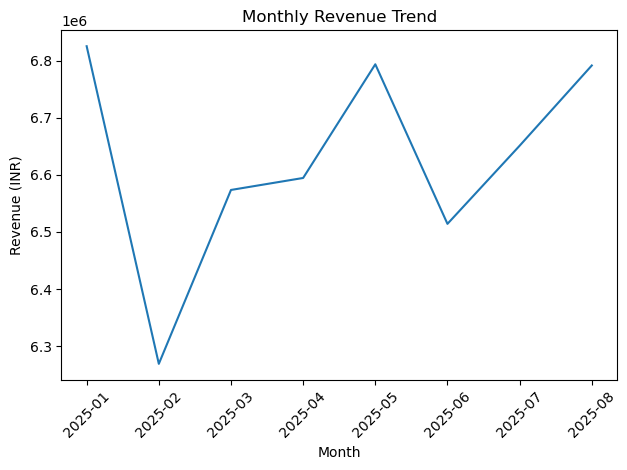

In [39]:
df ["Order Date"] = pd.to_datetime(df ["Order Date"])

df ["YearMonth"] = df ["Order Date"].dt.to_period("M").astype(str)

monthly_revenue = df.groupby ("YearMonth") ["Price (INR)"].sum().reset_index()

plt.figure()

plt.plot(monthly_revenue ["YearMonth"], monthly_revenue ["Price (INR)"])

plt.xticks (rotation=45)

plt.xlabel("Month")

plt.ylabel("Revenue (INR)")

plt.title("Monthly Revenue Trend")

plt.tight_layout()

plt.show()

### Daily Sales Trend

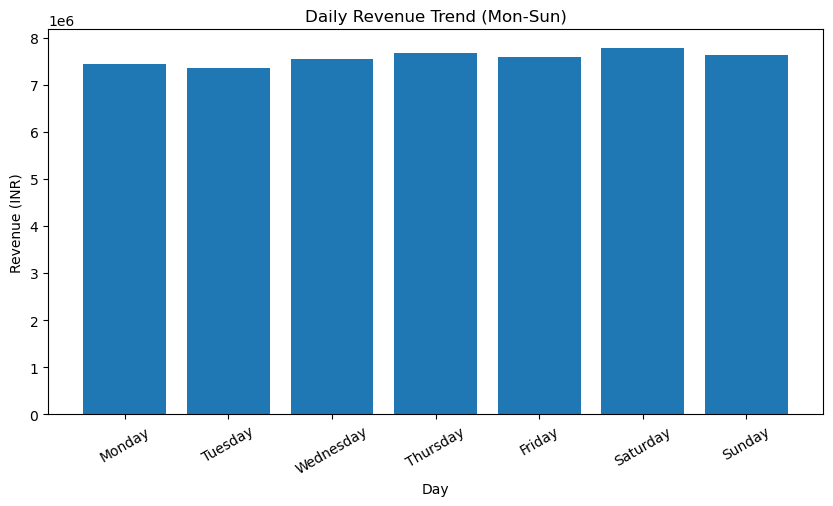

In [41]:
df["DayName"] = pd.to_datetime(df["Order Date"]).dt.day_name()

daily_revenue = (
    df.groupby("DayName")["Price (INR)"]
      .sum()
      .reindex(["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"])
)

plt.figure(figsize=(10, 5))
plt.bar(daily_revenue.index, daily_revenue.values)
plt.title("Daily Revenue Trend (Mon-Sun)")
plt.xlabel("Day")
plt.ylabel("Revenue (INR)")
plt.xticks(rotation=30)
plt.show()

### Total Sales by Food Type (Veg vs Non-Veg)


In [43]:
non_veg_keywords = [
    "chicken", "egg", "fish", "mutton",
    "prawn", "biryani", "kabab", "kebab",
    "non-veg", "non veg"
]

df["Food Category"] = np.where(
    df["Dish Name"].str.lower().str.contains("|".join(non_veg_keywords), na=False),
    "Non-Veg",
    "Veg"
)

In [ ]:
df["Food Category"] = np.where(
    df["Dish Name"].str.lower().str.contains("|".join(non_veg_keywords), na=False),
    "Non-Veg",
    "Veg"
)

food_revenue = df.groupby("Food Category")["Price (INR)"].sum().reset_index()

In [48]:
food_revenue = df.groupby("Food Category")["Price (INR)"].sum().reset_index()

fig = px.pie(
    food_revenue,
    values="Price (INR)",
    names="Food Category",
    hole=0.5,
    title="Revenue Contribution: Veg vs Non-Veg",
)

fig.update_traces(
    textinfo="percent+label",
    pull=[0.05, 0],
)

fig.update_layout(
    height=500,
    margin=dict(t=60, b=40, l=40, r=40),
)

fig.show()

### Total Sales by State

In [50]:
state_revenue = (
    df.groupby("State", as_index=False)["Price (INR)"]
      .sum()
      .sort_values("Price (INR)", ascending=False)
)

fig = px.bar(
    state_revenue,
    x="Price (INR)",
    y="State",
    orientation="h",
    title="Revenue by State (INR)",
)

fig.update_layout(height=600, yaxis=dict(autorange="reversed"))
fig.show()

In [52]:
# Quarterly Performance Summary

df["Order_Date"] = pd.to_datetime(df["Order Date"])

df["Quarter"] = df["Order_Date"].dt.to_period("Q").astype(str)

quarterly_summary = (
    df.groupby("Quarter", as_index=False)
      .agg(
          Total_Sales=("Price (INR)", "sum"),
          Avg_Rating=("Rating", "mean"),
          Total_Orders=("Order_Date", "count"),
      )
      .sort_values("Quarter")
)

quarterly_summary["Total_Sales"] = quarterly_summary["Total_Sales"].round(0)
quarterly_summary["Avg_Rating"] = quarterly_summary["Avg_Rating"].round(2)

quarterly_summary

,Quarter,Total_Sales,Avg_Rating,Total_Orders
0,2025Q1,19667822.0,4.34,73096
1,2025Q2,19902257.0,4.34,74163
2,2025Q3,13442427.0,4.34,50171


### Quarterly Performance Summary

In [53]:
df["Order_Date"] = pd.to_datetime(df["Order Date"])

df["Quarter"] = df ["Order_Date"].dt.to_period("Q").astype(str)

quarterly_summary = (

df.groupby("Quarter", as_index=False)

.agg(

Total_Sales=("Price (INR)", "sum"),

Avg_Rating=("Rating", "mean"),

Total_Orders=("Order_Date", "count")

)

.sort_values("Quarter")

)

quarterly_summary ["Total_Sales"] = quarterly_summary["Total_Sales"].round(0)

quarterly_summary["Avg_Rating"] = quarterly_summary["Avg_Rating"].round(2)

quarterly_summary

,Quarter,Total_Sales,Avg_Rating,Total_Orders
0,2025Q1,19667822.0,4.34,73096
1,2025Q2,19902257.0,4.34,74163
2,2025Q3,13442427.0,4.34,50171


### Top 5 Cities by Sales

In [55]:
top_5_cities = (
    df.groupby("City")["Price (INR)"]
      .sum()
      .nlargest(5)
      .reset_index()
      .sort_values("Price (INR)")
)

fig = px.bar(
    top_5_cities,
    x="Price (INR)",
    y="City",
    orientation="h",
    title="Top 5 Cities by Sales (INR)",
    color_discrete_sequence=["red"],
)

fig.show()